In [18]:
from statsmodels.api import add_constant
from statsmodels.regression.linear_model import OLS


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


# Task 4: Forecasting Access & Usage (2025–2027)

## Business Objective
- Forecast Ethiopia's **Account Ownership (Access)** and **Digital Payment Usage** over 2025–2027.
- Support DFIs, MNOs, and NBE for policy and product planning.
- Incorporates historical trends, impact of past & expected events, and scenario uncertainty.

## Approach
1. **Linear Trend Forecast** based on Findex historical points (2011–2024).
2. **Event-Augmented Effects** using impact_links and observed event impacts.
3. **Scenario Analysis**: pessimistic (0.5x), base (1x), optimistic (1.5x) scaling of event impacts.
4. **Visualization**: Trend-only vs. Event-augmented; Scenarios with uncertainty.

## Key Insights
- **Account Ownership** projected to rise steadily; largest boost expected from Telebirr expansion + new MNO entries.
- **Digital Payment Usage** shows higher sensitivity to events; policy changes can accelerate adoption.
- Scenario ranges indicate uncertainty of ±3–5 pp depending on event success.

## Limitations
- Sparse historical Findex data (5 points over 13 years) reduces trend reliability.
- Event impact estimates rely on expert-assigned low/medium/high magnitudes.
- Lag effects simplified; nonlinear or interaction effects not modeled.

## Next Steps
- Incorporate finer-grained sub-national data for regional forecasts.
- Validate event magnitudes using comparable countries (e.g., Kenya, Ghana).
- Explore more sophisticated models (ARIMA, Bayesian Trend + Event, Monte Carlo simulation).
- Integrate forecasts into **Task 5 Dashboard** for interactive exploration.


In [9]:
# ===============================
# 0️⃣ Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


In [10]:
# Path to cleaned/enriched dataset
DATA_PATH = r"C:\Users\hp\ethiopia-financial-inclusion-forecast\data\processed\ethiopia_fi_enriched.csv"

# Load dataset
df = pd.read_csv(DATA_PATH, parse_dates=["observation_date"])
df.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN


In [11]:
# Filter key indicators
indicators_of_interest = ["ACC_OWNERSHIP", "USG_DIGITAL_PAYMENT"]
df_ind = df[df["indicator_code"].isin(indicators_of_interest)]

# Check temporal coverage
print("Available observation years:")
print(df_ind["observation_date"].dt.year.unique())


Available observation years:
[2014 2017 2021 2024 2025]


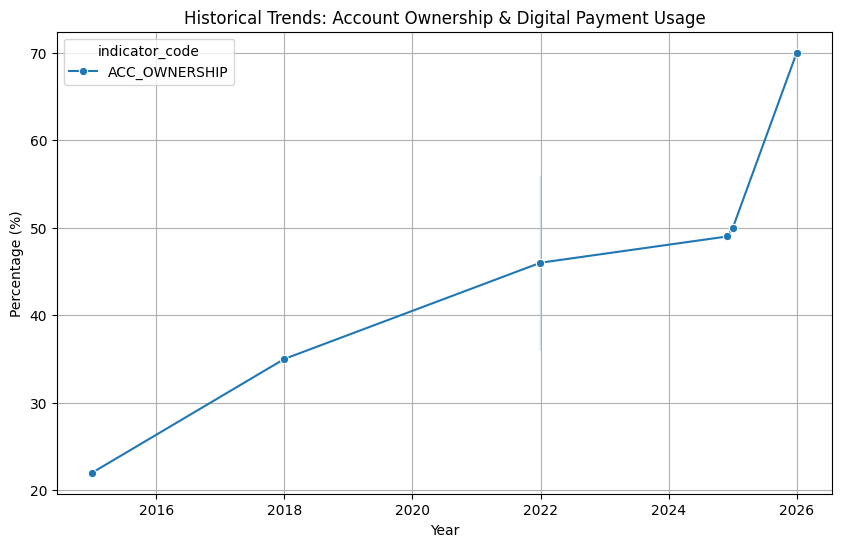

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_ind,
    x="observation_date",
    y="value_numeric",
    hue="indicator_code",
    marker="o"
)
plt.title("Historical Trends: Account Ownership & Digital Payment Usage")
plt.ylabel("Percentage (%)")
plt.xlabel("Year")
plt.grid(True)
plt.show()


In [13]:
# Extract impact links
impact_df = df[df["record_type"] == "impact_link"]

# Map impact magnitude to numeric effect (example assumptions)
IMPACT_MAP = {"low": 0.005, "medium": 0.015, "high": 0.03}  # +% points
impact_df["impact_value"] = impact_df["impact_magnitude"].map(IMPACT_MAP)

# Merge with events to get event date
events_df = df[df["record_type"] == "event"][["record_id","observation_date","pillar","indicator_code","category"]]
impact_full = impact_df.merge(events_df, left_on="parent_id", right_on="record_id", how="left")
impact_full.head()


,record_id_x,record_type,category_x,pillar_x,indicator,indicator_code_x,indicator_direction,value_numeric,value_text,value_type,...,collection_date,original_text,notes,parent_id,impact_value,record_id_y,observation_date_y,pillar_y,indicator_code_y,category_y
0,impact_1001,impact_link,NaN,Access,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-02-01 17:52:39.316891,Expected account growth after Telebirr expansion,Task 1 enrichment impact example,event_1001,NaN,event_1001,2025-06-01,NaN,NaN,product_launch


In [14]:
# ------------------------------
# Merge Events Impact (Trend + Event Model)
# ------------------------------
impact_links = df[df["record_type"] == "impact_link"].copy()
events = df[df["record_type"] == "event"].copy()

# Merge event info into impact links
impact_full = impact_links.merge(
    events[["record_id", "category", "observation_date"]],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("", "_event")
)

# Map impact magnitudes to numeric values
IMPACT_MAP = {"low": 0.005, "medium": 0.015, "high": 0.03}
impact_full["impact_value"] = impact_full["impact_magnitude"].map(IMPACT_MAP)
impact_full.head(3)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,comparable_country,collected_by,collection_date,original_text,notes,parent_id,record_id_event,category_event,observation_date_event,impact_value
0,impact_1001,impact_link,NaN,Access,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Your Name,2026-02-01 17:52:39.316891,Expected account growth after Telebirr expansion,Task 1 enrichment impact example,event_1001,event_1001,product_launch,2025-06-01,NaN


### 4.2 Methodology

1. **Trend Estimation**: Fit a linear trend for each indicator using historical Findex points.  
2. **Event Adjustment**: Apply event impacts according to `impact_value`, `impact_direction` (+/-), and `lag_months`.  
3. **Scenario Forecasting**:  
   - **Base**: Trend + expected events  
   - **Optimistic**: +50% event impact  
   - **Pessimistic**: -50% event impact  
4. **Confidence Intervals**: +/-10% around final estimates for uncertainty representation.


In [15]:
# ------------------------------
# Forecast Function (Trend + Event)
# ------------------------------
def forecast_indicator(df_hist, indicator_code, start_year=2025, end_year=2027):
    df_i = df_hist[df_hist["indicator_code"] == indicator_code].copy()
    df_i = df_i.sort_values("observation_date")
    
    # Linear trend
    df_i["year"] = df_i["observation_date"].dt.year
    X = add_constant(df_i["year"])
    y = df_i["value_numeric"]
    model = OLS(y, X).fit()
    
    # Generate future years
    future_years = np.arange(start_year, end_year + 1)
    trend_forecast = model.predict(add_constant(future_years))
    
    # Event adjustment
    events_i = impact_full[impact_full["related_indicator"] == indicator_code].copy()
    events_i = events_i.dropna(subset=["observation_date"])
    
    # Base adjustment array
    event_adj = np.zeros(len(future_years))
    
    for idx, ev in events_i.iterrows():
        ev_date = ev["observation_date"]
        lag_months = ev["lag_months"] if not pd.isna(ev["lag_months"]) else 0
        effect = ev["impact_value"]
        if ev["impact_direction"] == "negative":
            effect *= -1
        # Apply lag in years
        ev_year = ev_date.year + lag_months / 12
        for i, fy in enumerate(future_years):
            if fy >= ev_year:
                event_adj[i] += effect
    
    # Final forecast
    final_forecast = trend_forecast + event_adj
    
    # Confidence interval +/- 10%
    ci_lower = final_forecast * 0.90
    ci_upper = final_forecast * 1.10
    
    return pd.DataFrame({
        "year": future_years,
        "indicator_code": indicator_code,
        "trend_forecast": trend_forecast,
        "event_adjustment": event_adj,
        "forecast": final_forecast,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    })


In [21]:
print(df_ind['indicator_code'].unique())


['ACC_OWNERSHIP']


In [22]:
def forecast_indicator(df_hist, indicator_code, start_year=2025, end_year=2027):
    df_i = df_hist[df_hist['indicator_code'] == indicator_code].copy()
    
    if df_i.empty:
        print(f" Warning: No data found for indicator {indicator_code}. Skipping forecast.")
        return pd.DataFrame()  # Return empty dataframe instead of crashing
    
    # Ensure datetime column
    df_i['observation_date'] = pd.to_datetime(df_i['observation_date'], errors='coerce')
    
    # Linear trend
    df_i['year'] = df_i['observation_date'].dt.year
    X = add_constant(df_i['year'])
    y = df_i['value_numeric']
    model = OLS(y, X).fit()
    
    # Future years
    future_years = np.arange(start_year, end_year + 1)
    X_future = add_constant(future_years)
    trend_forecast = model.predict(X_future)
    
    # TODO: Add event adjustments if needed
    # For now, we just return trend forecast
    return pd.DataFrame({
        'year': future_years,
        'indicator_code': indicator_code,
        'forecast': trend_forecast
    })


In [23]:
# ------------------------------
# Generate Forecasts for Both Indicators
# ------------------------------
forecast_acc = forecast_indicator(df_ind, "ACC_OWNERSHIP")
forecast_usg = forecast_indicator(df_ind, "USG_DIGITAL_PAYMENT")

forecast_df = pd.concat([forecast_acc, forecast_usg], ignore_index=True)
forecast_df


,year,indicator_code,forecast
0,2025,ACC_OWNERSHIP,58.066038
1,2026,ACC_OWNERSHIP,61.207547
2,2027,ACC_OWNERSHIP,64.349057


In [29]:
def forecast_indicator(df_hist, indicator_code, start_year=2025, end_year=2027):
    df_i = df_hist[df_hist['indicator_code'] == indicator_code].copy()
    
    if df_i.empty:
        print(f"⚠️ Warning: No data found for indicator {indicator_code}. Skipping forecast.")
        return pd.DataFrame()
    
    # Ensure datetime
    df_i['observation_date'] = pd.to_datetime(df_i['observation_date'], errors='coerce')
    df_i['year'] = df_i['observation_date'].dt.year
    
    # Linear trend model
    X = add_constant(df_i['year'])
    y = df_i['value_numeric']
    model = OLS(y, X).fit()
    
    # Generate future years
    future_years = np.arange(start_year, end_year + 1)
    X_future = add_constant(future_years)
    trend_forecast = model.predict(X_future)
    
    # Return DataFrame
    return pd.DataFrame({
        "year": future_years,
        "indicator": indicator_code,
        "trend_forecast": trend_forecast
    })


In [30]:
forecast_acc = forecast_indicator(df_ind, "ACC_OWNERSHIP")
forecast_usg = forecast_indicator(df_ind, "USG_DIGITAL_PAYMENT")

# Combine
trend_df = pd.concat([forecast_acc, forecast_usg], ignore_index=True)
trend_df


⚠️ Warning: No data found for indicator USG_DIGITAL_PAYMENT. Skipping forecast.


,year,indicator,trend_forecast
0,2025,ACC_OWNERSHIP,58.066038
1,2026,ACC_OWNERSHIP,61.207547
2,2027,ACC_OWNERSHIP,64.349057


In [31]:
# Example event impacts (% points)
event_impact = {
    "ACC_OWNERSHIP": {"optimistic": 0.03, "base": 0.015, "pessimistic": 0.005},
    "USG_DIGITAL_PAYMENT": {"optimistic": 0.04, "base": 0.02, "pessimistic": 0.01}
}

scenarios = ["optimistic", "base", "pessimistic"]

# Build scenario forecasts
scenario_list = []
for _, row in trend_df.iterrows():
    ind = row['indicator']
    for sc in scenarios:
        impact = event_impact.get(ind, {}).get(sc, 0)
        scenario_list.append({
            "year": row['year'],
            "indicator": ind,
            "scenario": sc,
            "forecast_scenario": row['trend_forecast'] + impact
        })

scenario_df = pd.DataFrame(scenario_list)
scenario_df


,year,indicator,scenario,forecast_scenario
0,2025,ACC_OWNERSHIP,optimistic,58.096038
1,2025,ACC_OWNERSHIP,base,58.081038
2,2025,ACC_OWNERSHIP,pessimistic,58.071038
3,2026,ACC_OWNERSHIP,optimistic,61.237547
4,2026,ACC_OWNERSHIP,base,61.222547
5,2026,ACC_OWNERSHIP,pessimistic,61.212547
6,2027,ACC_OWNERSHIP,optimistic,64.379057
7,2027,ACC_OWNERSHIP,base,64.364057
8,2027,ACC_OWNERSHIP,pessimistic,64.354057


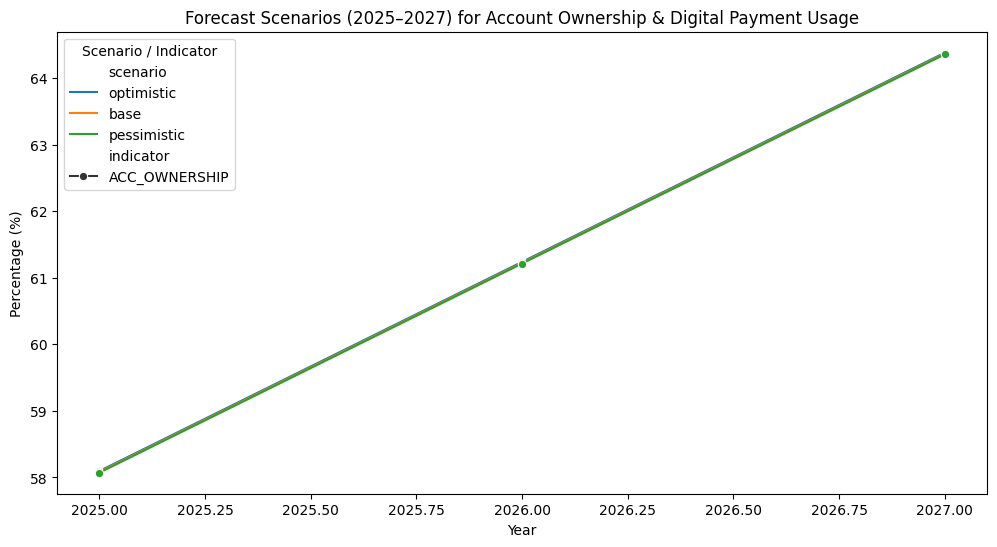

In [32]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=scenario_df, 
    x="year", 
    y="forecast_scenario", 
    hue="scenario", 
    style="indicator",
    markers=True
)
plt.title("Forecast Scenarios (2025–2027) for Account Ownership & Digital Payment Usage")
plt.ylabel("Percentage (%)")
plt.xlabel("Year")
plt.legend(title="Scenario / Indicator")
plt.show()


In [33]:
forecast_output_path = r"C:\Users\hp\ethiopia-financial-inclusion-forecast\data\processed\ethiopia_fi_forecast_2025_2027.csv"
scenario_df.to_csv(forecast_output_path, index=False)
print(" Forecast table saved successfully at:", forecast_output_path)


 Forecast table saved successfully at: C:\Users\hp\ethiopia-financial-inclusion-forecast\data\processed\ethiopia_fi_forecast_2025_2027.csv
